# 1. Install Dependencies and Setup

In [ ]:
!pip list

In [1]:
import tensorflow as tf
import os

In [2]:
# Avoid OOM errors by setting GPU Memory Consumption Growth
gpus = tf.config.experimental.list_physical_devices('GPU')
for gpu in gpus: 
    tf.config.experimental.set_memory_growth(gpu, True)

In [3]:
tf.config.list_physical_devices('GPU')

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]

# 2. Remove dodgy images

In [4]:
import cv2
import imghdr

In [5]:
data_dir = 'data' 

In [6]:
image_exts = ['jpeg','jpg', 'bmp', 'png']

In [7]:
for image_class in os.listdir(data_dir): 
    for image in os.listdir(os.path.join(data_dir, image_class)):
        image_path = os.path.join(data_dir, image_class, image)
        try: 
            img = cv2.imread(image_path)
            tip = imghdr.what(image_path)
            if tip not in image_exts: 
                print('Image not in ext list {}'.format(image_path))
                os.remove(image_path)
        except Exception as e: 
            print('Issue with image {}'.format(image_path))
            # os.remove(image_path)

# 3. Load Data

In [8]:
import numpy as np
from matplotlib import pyplot as plt

In [ ]:
data = tf.keras.utils.image_dataset_from_directory('data')

In [10]:
data_iterator = data.as_numpy_iterator()

In [11]:
batch = data_iterator.next()

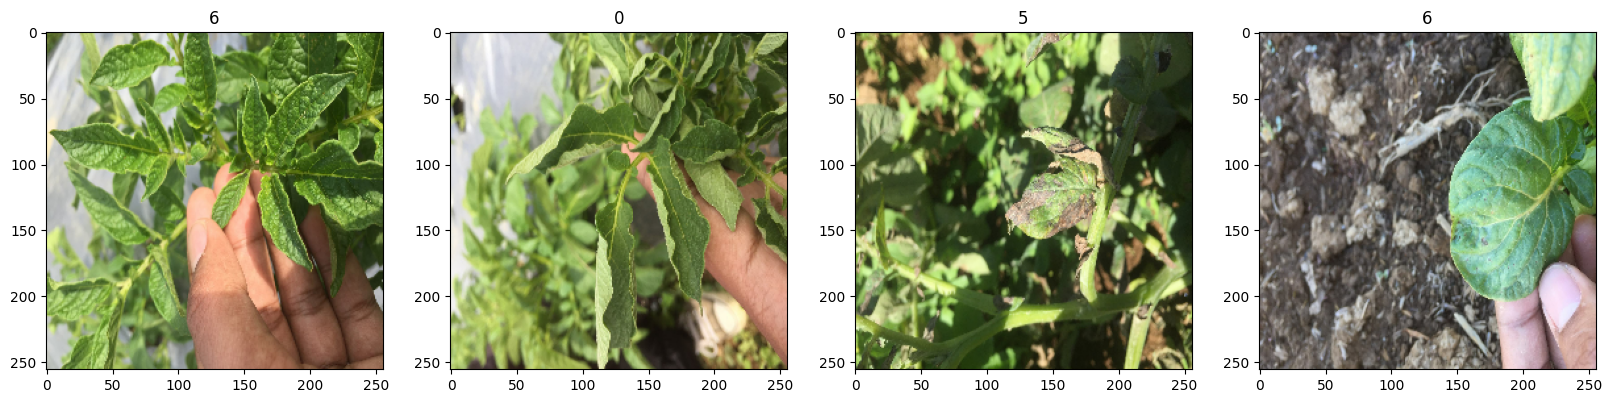

In [12]:
fig, ax = plt.subplots(ncols=4, figsize=(20,20))
for idx, img in enumerate(batch[0][:4]):
    ax[idx].imshow(img.astype(int))
    ax[idx].title.set_text(batch[1][idx])

# 4. Scale Data

In [13]:
data = data.map(lambda x,y: (x/255, y))

In [14]:
data.as_numpy_iterator().next()

(array([[[[0.47395834, 0.5249387 , 0.55631125],
          [0.53878057, 0.5740747 , 0.5936825 ],
          [0.57848763, 0.6098602 , 0.6216249 ],
          ...,
          [0.42512256, 0.3466912 , 0.24080883],
          [0.41859993, 0.34136653, 0.21315272],
          [0.27687198, 0.23587623, 0.15279923]],
 
         [[0.49635416, 0.54733455, 0.5787071 ],
          [0.55048084, 0.58577496, 0.6053828 ],
          [0.5809743 , 0.6123468 , 0.62411153],
          ...,
          [0.35511643, 0.29237133, 0.19433211],
          [0.34438404, 0.2785233 , 0.1773684 ],
          [0.24310662, 0.19212623, 0.12306363]],
 
         [[0.48746938, 0.5367034 , 0.5686581 ],
          [0.5444089 , 0.57970303, 0.5993109 ],
          [0.57313114, 0.6045037 , 0.6162684 ],
          ...,
          [0.28853616, 0.23973101, 0.1528744 ],
          [0.30248162, 0.2436581 , 0.16096862],
          [0.24501115, 0.19403076, 0.13103554]],
 
         ...,
 
         [[0.4579913 , 0.5050501 , 0.5677952 ],
          [0.45301

# 5. Split Data

In [15]:
train_size = int(len(data)*.7)
val_size = int(len(data)*.2)
test_size = int(len(data)*.1)

In [16]:
train_size

29

In [17]:
train = data.take(train_size)
val = data.skip(train_size).take(val_size)
test = data.skip(train_size+val_size).take(test_size)

# 6. Build Deep Learning Model

In [18]:
train

<TakeDataset element_spec=(TensorSpec(shape=(None, 256, 256, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))>

In [19]:
import os
import tensorflow as tf
import numpy as np

# 1. OPTIONAL: Hide extra system warnings
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

# 2. GPU Memory Growth Fix (Prevents crashes on modern GPUs)
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print("Successfully found GPU and set memory growth.")
    except RuntimeError as e:
        print(f"GPU Error: {e}")

# 3. Load Dataset
# Note: Ensure your 'data' folder has 7 subfolders for this specific code.
data = tf.keras.utils.image_dataset_from_directory(
    'data',
    image_size=(256, 256),
    batch_size=32,
    label_mode='int' # This produces integers (0, 1, 2...) for SparseCategoricalCrossentropy
)

# Scale images from [0, 255] to [0, 1]
data = data.map(lambda x, y: (x / 255.0, y))

# Split data (80% train, 20% validation)
train_size = int(len(data) * 0.8)
train = data.take(train_size)
val = data.skip(train_size)

# 4. Build Model (Transfer Learning with MobileNetV2)
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.applications import MobileNetV2

def create_transfer_learning_model():
    # include_top=False removes the final classification layer of MobileNet
    base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(256, 256, 3))
    base_model.trainable = False  # Freeze the pre-trained weights

    model = Sequential([
        base_model,
        GlobalAveragePooling2D(),
        Dense(128, activation='relu'),
        Dropout(0.4),
        Dense(7, activation='softmax') # Match this '7' to your folder count
    ])
    return model

model = create_transfer_learning_model()

# 5. Compile
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy', # Used because labels are integers
    metrics=['accuracy']
)

# 6. Train
# If it hangs at the start of Epoch 1, remember it's just JIT-compiling for your GPU!
print("Starting training...")
hist = model.fit(
    train,
    epochs=20,
    validation_data=val
)

# 7. Verification
print("\nTraining Complete!")

GPU Error: Physical devices cannot be modified after being initialized
Found 1317 files belonging to 7 classes.
Starting training...
Epoch 1/20
33/33 [==============================] - 80s 220ms/step - loss: 1.6318 - accuracy: 0.3845 - val_loss: 1.0496 - val_accuracy: 0.6513
Epoch 2/20
33/33 [==============================] - 9s 252ms/step - loss: 1.0998 - accuracy: 0.5900 - val_loss: 0.8849 - val_accuracy: 0.6858
Epoch 3/20
33/33 [==============================] - 9s 248ms/step - loss: 0.9429 - accuracy: 0.6591 - val_loss: 0.7405 - val_accuracy: 0.7510
Epoch 4/20
33/33 [==============================] - 8s 225ms/step - loss: 0.7714 - accuracy: 0.7358 - val_loss: 0.5529 - val_accuracy: 0.8276
Epoch 5/20
33/33 [==============================] - 8s 235ms/step - loss: 0.6675 - accuracy: 0.7699 - val_loss: 0.5140 - val_accuracy: 0.8544
Epoch 6/20
33/33 [==============================] - 8s 224ms/step - loss: 0.5697 - accuracy: 0.7898 - val_loss: 0.4874 - val_accuracy: 0.8582
Epoch 7/20
33/

In [20]:
model.compile('adam', loss=tf.losses.BinaryCrossentropy(), metrics=['accuracy'])

In [21]:
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 mobilenetv2_1.00_224 (Funct  (None, 8, 8, 1280)       2257984   
 ional)                                                          
                                                                 
 global_average_pooling2d (G  (None, 1280)             0         
 lobalAveragePooling2D)                                          
                                                                 
 dense (Dense)               (None, 128)               163968    
                                                                 
 dropout (Dropout)           (None, 128)               0         
                                                                 
 dense_1 (Dense)             (None, 7)                 903       
                                                                 
Total params: 2,422,855
Trainable params: 164,871
Non-tr

# 7. Train

In [22]:
logdir='logs'

In [25]:
tensorboard_callback = tf.keras.callbacks.TensorBoard(log_dir=logdir)

In [26]:
hist = model.fit(train, epochs=20, validation_data=val, callbacks=[tensorboard_callback])

Epoch 1/20


ValueError: in user code:

    File "C:\Users\karus\LeafClassification\potatoleaf\lib\site-packages\keras\engine\training.py", line 1160, in train_function  *
        return step_function(self, iterator)
    File "C:\Users\karus\LeafClassification\potatoleaf\lib\site-packages\keras\engine\training.py", line 1146, in step_function  **
        outputs = model.distribute_strategy.run(run_step, args=(data,))
    File "C:\Users\karus\LeafClassification\potatoleaf\lib\site-packages\keras\engine\training.py", line 1135, in run_step  **
        outputs = model.train_step(data)
    File "C:\Users\karus\LeafClassification\potatoleaf\lib\site-packages\keras\engine\training.py", line 994, in train_step
        loss = self.compute_loss(x, y, y_pred, sample_weight)
    File "C:\Users\karus\LeafClassification\potatoleaf\lib\site-packages\keras\engine\training.py", line 1052, in compute_loss
        return self.compiled_loss(
    File "C:\Users\karus\LeafClassification\potatoleaf\lib\site-packages\ker

# 8. Plot Performance

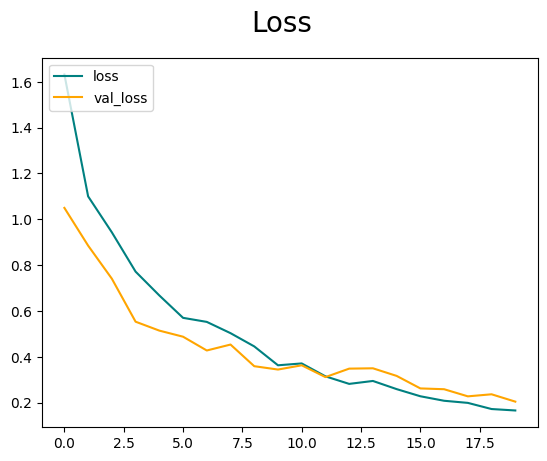

In [23]:
fig = plt.figure()
plt.plot(hist.history['loss'], color='teal', label='loss')
plt.plot(hist.history['val_loss'], color='orange', label='val_loss')
fig.suptitle('Loss', fontsize=20)
plt.legend(loc="upper left")
plt.show()

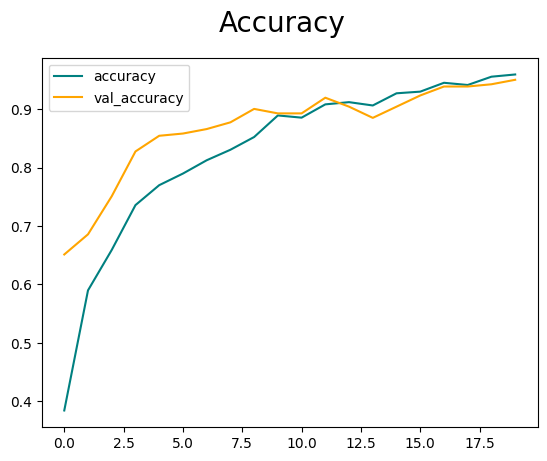

In [24]:
fig = plt.figure()
plt.plot(hist.history['accuracy'], color='teal', label='accuracy')
plt.plot(hist.history['val_accuracy'], color='orange', label='val_accuracy')
fig.suptitle('Accuracy', fontsize=20)
plt.legend(loc="upper left")
plt.show()

In [28]:
model.save('potato_model.h5')
print("Model saved as potato_model.h5")

Model saved as potato_model.h5


# 9. Evaluate

In [25]:
from tensorflow.keras.metrics import Precision, Recall, BinaryAccuracy

In [26]:
pre = Precision()
re = Recall()
acc = BinaryAccuracy()

In [27]:
for batch in test.as_numpy_iterator(): 
    X, y = batch
    yhat = model.predict(X)
    pre.update_state(y, yhat)
    re.update_state(y, yhat)
    acc.update_state(y, yhat)

1/1 [==============================] - 1s 863ms/step


ValueError: Shapes (32, 7) and (32,) are incompatible

In [32]:
print(pre.result(), re.result(), acc.result())

tf.Tensor(1.0, shape=(), dtype=float32) tf.Tensor(1.0, shape=(), dtype=float32) tf.Tensor(1.0, shape=(), dtype=float32)


# 10. Test

In [33]:
import cv2

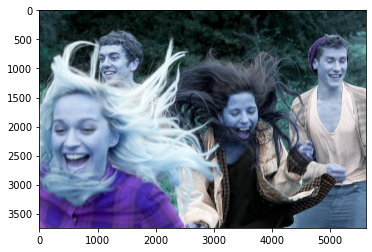

In [39]:
img = cv2.imread('154006829.jpg')
plt.imshow(img)
plt.show()

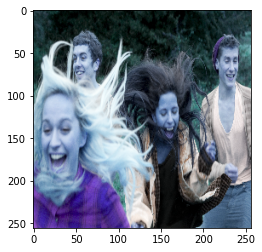

In [40]:
resize = tf.image.resize(img, (256,256))
plt.imshow(resize.numpy().astype(int))
plt.show()

In [41]:
yhat = model.predict(np.expand_dims(resize/255, 0))

In [42]:
yhat

array([[0.01972741]], dtype=float32)

In [43]:
if yhat > 0.5: 
    print(f'Predicted class is Sad')
else:
    print(f'Predicted class is Happy')

Predicted class is Happy


# 11. Save the Model

In [44]:
from tensorflow.keras.models import load_model

In [45]:
model.save(os.path.join('models','imageclassifier.h5'))

In [46]:
new_model = load_model('imageclassifier.h5')

In [47]:
new_model.predict(np.expand_dims(resize/255, 0))

array([[0.01972741]], dtype=float32)